# 05_data_cleaning.ipynb

Notebook này dùng để:
- Đọc dữ liệu FER-2013 dạng `emotion, pixels, Usage`
- Phát hiện ảnh lỗi / ảnh nghi ngờ
- Trực quan các ảnh bị gắn cờ
- Xuất file danh sách ảnh lỗi và file dữ liệu đã clean


## 1. Import thư viện

In [35]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 2. Cấu hình đường dẫn

Bạn sửa `DATA_PATH` cho đúng với file của bạn.

Có thể dùng:
- `.csv`
- `.xlsx`


In [36]:
# =========================
# CONFIG
# =========================
DATA_PATH = '../../data/train.csv'   # ví dụ: 'fer2013.csv' hoặc 'fer2013.xlsx'
OUTPUT_DIR = '../../data/fer_data/cleaning_outputs'
IMAGE_SIZE = 48
PIXEL_COUNT = IMAGE_SIZE * IMAGE_SIZE

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR)


Output dir: ../../data/fer_data/cleaning_outputs


## 3. Đọc dữ liệu

In [37]:
def load_data(path):
    path = str(path)
    if path.lower().endswith('.csv'):
        df = pd.read_csv(path)
    elif path.lower().endswith('.xlsx') or path.lower().endswith('.xls'):
        df = pd.read_excel(path)
    else:
        raise ValueError('Chỉ hỗ trợ .csv hoặc .xlsx/.xls')

    required_cols = {'emotion', 'pixels', 'Usage'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Thiếu cột: {missing}')

    df = df.copy()
    df['row_id'] = np.arange(len(df))
    return df

df = load_data(DATA_PATH)
print('Shape:', df.shape)
display(df.head())


Shape: (28709, 4)


,emotion,pixels,Usage,row_id
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,0
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,1
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,2
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,3
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,4


## 4. Hàm parse ảnh từ chuỗi pixels

Dữ liệu pixel dạng:
`170 118 101 88 88 75 ...`

Ta dùng `np.fromstring(..., sep=' ')` để parse nhanh hơn `split()` + `map(int, ...)`.


In [38]:
def parse_pixels_fast(pixel_str):
    return np.fromstring(str(pixel_str), dtype=np.uint8, sep=' ')

sample_arr = parse_pixels_fast(df.loc[0, 'pixels'])
print('Số pixel của dòng đầu tiên:', len(sample_arr))
print(sample_arr[:20])


Số pixel của dòng đầu tiên: 2304
[ 70  80  82  72  58  58  60  63  54  58  60  48  89 115 121 119 115 110
  98  91]


## 5. Hàm tính entropy

Entropy giúp nhận diện ảnh quá nghèo thông tin, quá phẳng, hoặc bất thường.
Ta chỉ dùng như một chỉ số bổ sung.


In [39]:
def compute_entropy(arr):
    if len(arr) == 0:
        return np.nan
    hist = np.bincount(arr, minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


## 6. Hàm kiểm tra chất lượng ảnh

Phân thành 3 nhóm:
- `ok`: ảnh bình thường
- `review`: ảnh nghi ngờ, cần xem lại
- `remove`: ảnh lỗi rõ ràng, nên loại khỏi training

Bạn có thể chỉnh các ngưỡng ở phần rule nếu cần.


In [40]:
def check_image_quality(pixel_str):
    arr = parse_pixels_fast(pixel_str)

    # parse lỗi hoặc sai length
    if len(arr) != PIXEL_COUNT:
        return {
            'valid_length': False,
            'pixel_count': len(arr),
            'mean': np.nan,
            'std': np.nan,
            'min': np.nan,
            'max': np.nan,
            'unique_count': 0,
            'zero_ratio': np.nan,
            'white_ratio': np.nan,
            'entropy': np.nan,
            'flag': 'remove',
            'reason': 'wrong_length'
        }

    mean_val = float(arr.mean())
    std_val = float(arr.std())
    min_val = int(arr.min())
    max_val = int(arr.max())
    unique_count = int(np.unique(arr).size)
    zero_ratio = float((arr == 0).mean())
    white_ratio = float((arr == 255).mean())
    entropy = compute_entropy(arr)

    # =========================
    # RULE REMOVE: lỗi khá chắc chắn
    # =========================
    if std_val < 1.5:
        flag, reason = 'remove', 'very_low_std'
    elif unique_count <= 3:
        flag, reason = 'remove', 'too_few_unique_values'
    elif mean_val < 5 or zero_ratio > 0.90:
        flag, reason = 'remove', 'almost_black'
    elif mean_val > 250 or white_ratio > 0.90:
        flag, reason = 'remove', 'almost_white'
    elif entropy < 0.30:
        flag, reason = 'remove', 'very_low_entropy'

    # =========================
    # RULE REVIEW: nghi ngờ
    # =========================
    elif std_val < 8:
        flag, reason = 'review', 'low_contrast'
    elif mean_val < 15:
        flag, reason = 'review', 'very_dark'
    elif mean_val > 240:
        flag, reason = 'review', 'very_bright'
    elif unique_count < 10:
        flag, reason = 'review', 'low_unique_values'
    elif entropy < 2.0:
        flag, reason = 'review', 'low_entropy'
    else:
        flag, reason = 'ok', 'ok'

    return {
        'valid_length': True,
        'pixel_count': len(arr),
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'unique_count': unique_count,
        'zero_ratio': zero_ratio,
        'white_ratio': white_ratio,
        'entropy': entropy,
        'flag': flag,
        'reason': reason
    }


## 7. Quét toàn bộ dataset

Đây là bước chính để tăng tốc:
- parse nhanh bằng NumPy
- chỉ tính các metric cần thiết
- chưa cần trực quan toàn bộ ảnh


In [41]:
results = df['pixels'].apply(check_image_quality)
quality_df = pd.DataFrame(results.tolist())

full_df = pd.concat([
    df[['row_id', 'emotion', 'Usage', 'pixels']].copy(),
    quality_df
], axis=1)

print('Hoàn tất quét dữ liệu.')
display(full_df.head())


Hoàn tất quét dữ liệu.


,row_id,emotion,Usage,pixels,valid_length,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy,flag,reason
0,0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,True,2304,117.592882,50.735357,11,210,190,0.000000,0.000000,7.316994,ok,ok
1,1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,True,2304,126.971354,40.854364,0,219,214,0.001736,0.000000,7.231241,ok,ok
2,2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,True,2304,160.814236,74.711745,0,255,254,0.015625,0.009549,7.670950,ok,ok
3,3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,True,2304,130.503472,59.357461,12,235,214,0.000000,0.000000,7.327695,ok,ok
4,4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,True,2304,97.900174,70.166311,0,241,234,0.077257,0.000000,7.488916,ok,ok


## 8. Thống kê kết quả

In [42]:
print('Phân bố flag:')
display(full_df['flag'].value_counts())

print('\nPhân bố reason:')
display(full_df['reason'].value_counts())

print('\nSố lượng theo Usage và flag:')
display(pd.crosstab(full_df['Usage'], full_df['flag']))


Phân bố flag:


flag
ok        28674
review       22
remove       13
Name: count, dtype: int64


Phân bố reason:


reason
ok              28674
very_bright        18
very_low_std       12
very_dark           4
almost_black        1
Name: count, dtype: int64


Số lượng theo Usage và flag:


flag,ok,remove,review
Usage,,,
Training,28674,13,22


## 9. Xem các mẫu bị gắn cờ

In [43]:
flagged_df = full_df[full_df['flag'] != 'ok'].copy()
display(flagged_df[['row_id', 'emotion', 'Usage', 'flag', 'reason', 'mean', 'std', 'unique_count', 'entropy']].head(30))


,row_id,emotion,Usage,flag,reason,mean,std,unique_count,entropy
2059,2059,5,Training,review,very_bright,245.425781,21.609312,122,3.504083
2171,2171,6,Training,remove,very_low_std,128.302951,0.637561,4,1.395017
2809,2809,5,Training,review,very_bright,248.087240,17.691603,86,2.207127
3262,3262,5,Training,review,very_bright,242.844618,23.055078,123,3.820714
3931,3931,2,Training,review,very_bright,242.663628,27.871670,122,2.721012
4275,4275,3,Training,review,very_bright,244.990885,25.411755,114,2.506066
5439,5439,0,Training,review,very_bright,244.865017,20.889996,97,3.272120
6458,6458,0,Training,remove,very_low_std,0.000000,0.000000,1,-0.000000
7172,7172,3,Training,review,very_bright,243.335938,24.200623,109,3.596212
7496,7496,0,Training,review,very_dark,10.575521,42.538906,121,1.267832


## 10. Hàm trực quan ảnh bị gắn cờ

Ta chỉ show những ảnh bị `review` hoặc `remove`, không show toàn bộ dataset.


In [44]:
def show_flagged_images(dataframe, flag='review', n=25, random_state=42):
    subset = dataframe[dataframe['flag'] == flag].copy()
    if len(subset) == 0:
        print(f'Không có ảnh nào thuộc nhóm: {flag}')
        return

    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)

    subset = subset.reset_index(drop=True)
    cols = 5
    rows = math.ceil(len(subset) / cols)

    plt.figure(figsize=(15, 3 * rows))
    for i, row in subset.iterrows():
        arr = parse_pixels_fast(row['pixels'])
        if len(arr) != PIXEL_COUNT:
            continue
        img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(
            f"id={row['row_id']}\n{row['flag']} | {row['reason']}\nemotion={row['emotion']}"
        )
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 11. Trực quan ảnh `remove` và `review`

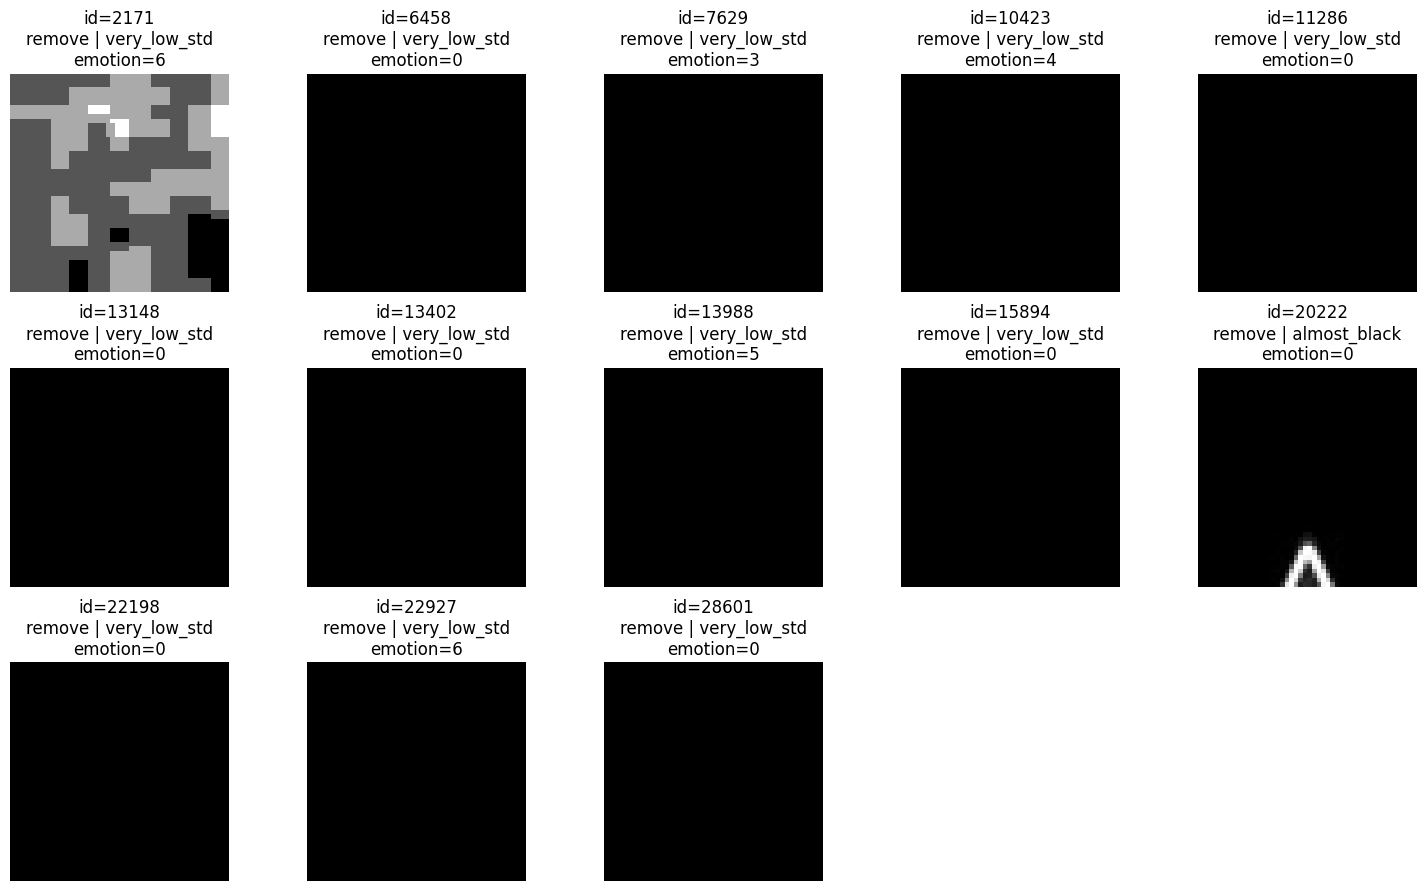

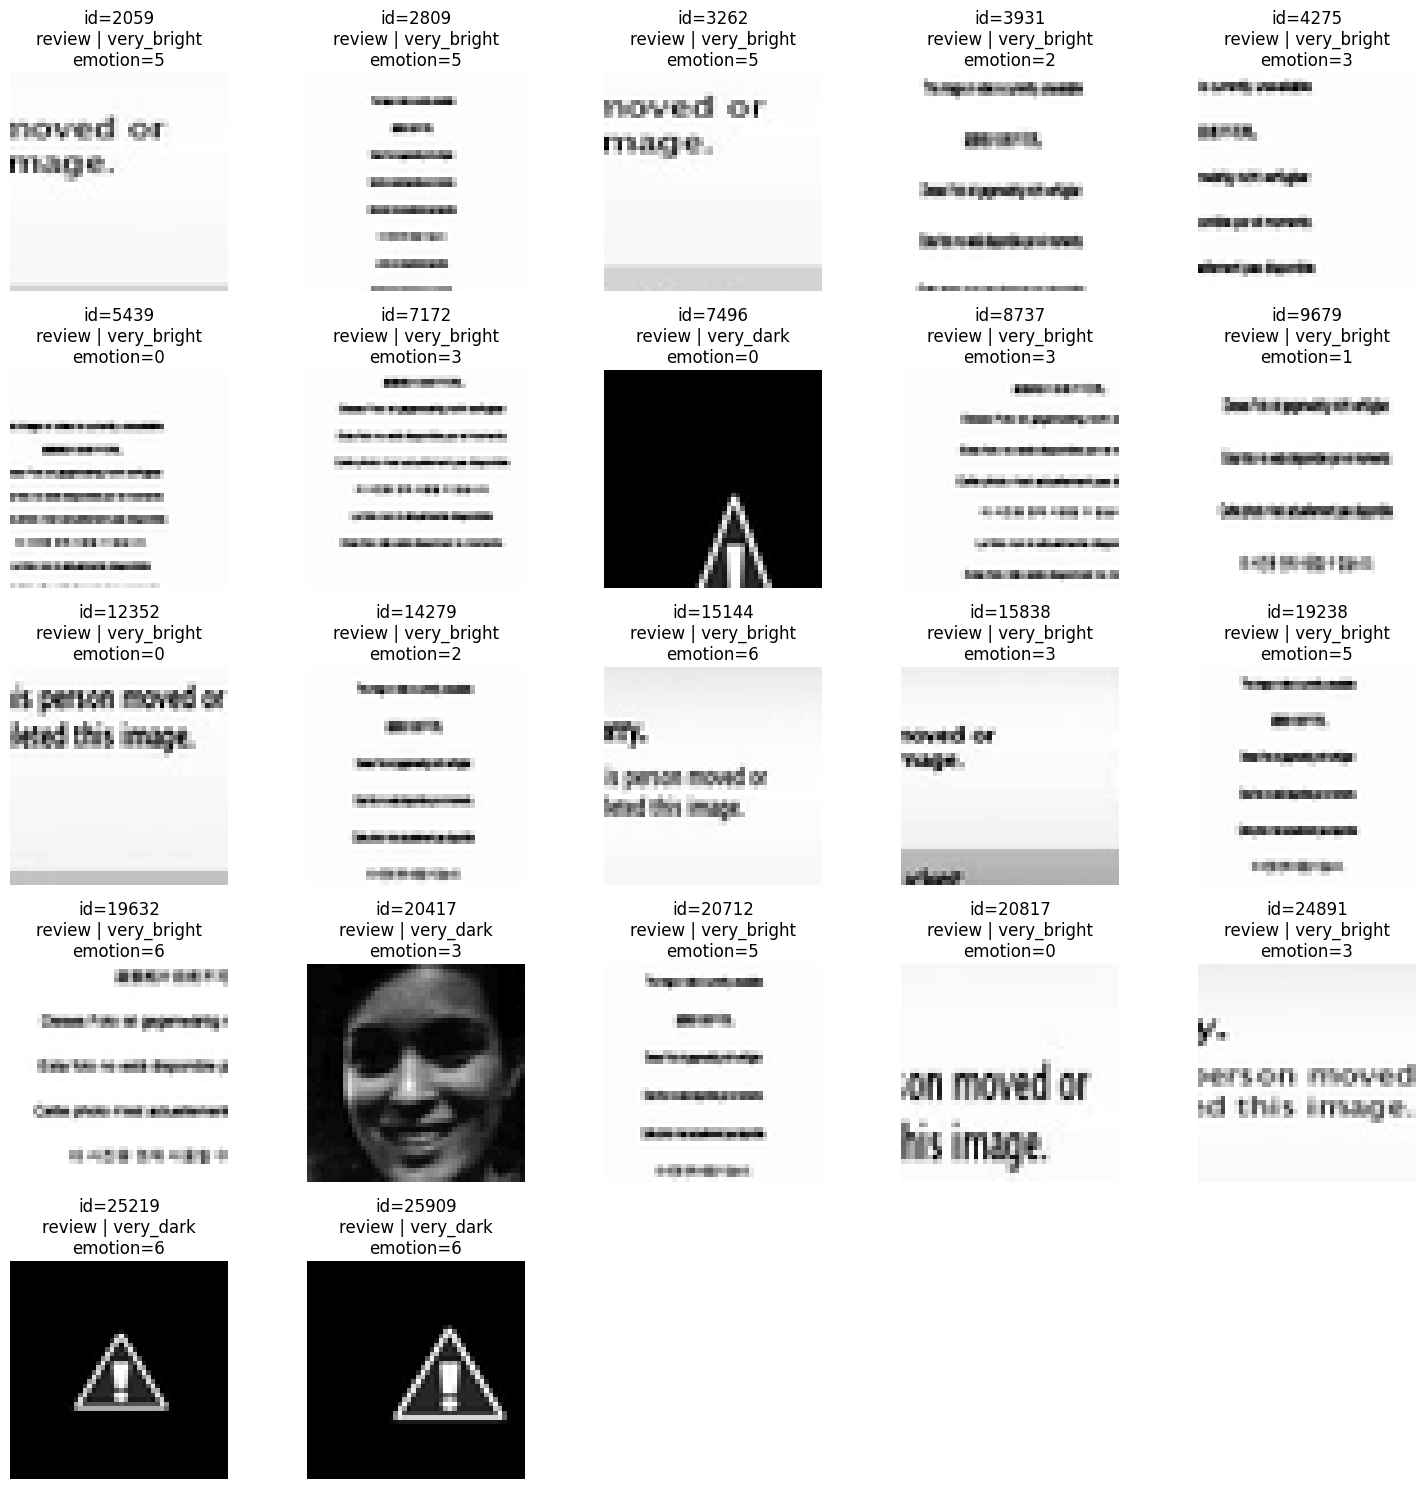

In [45]:
show_flagged_images(full_df, flag='remove', n=25)
show_flagged_images(full_df, flag='review', n=25)


## 12. Trực quan theo từng lý do cụ thể

Ví dụ: chỉ xem ảnh `almost_black` hoặc `low_contrast`.


In [46]:
def show_by_reason(dataframe, reason='almost_black', n=25, random_state=42):
    subset = dataframe[dataframe['reason'] == reason].copy()
    if len(subset) == 0:
        print(f'Không có ảnh nào với reason: {reason}')
        return

    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)

    subset = subset.reset_index(drop=True)
    cols = 5
    rows = math.ceil(len(subset) / cols)

    plt.figure(figsize=(15, 3 * rows))
    for i, row in subset.iterrows():
        arr = parse_pixels_fast(row['pixels'])
        if len(arr) != PIXEL_COUNT:
            continue
        img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(
            f"id={row['row_id']}\n{row['reason']}\nstd={row['std']:.2f}, ent={row['entropy']:.2f}"
        )
        plt.axis('off')
    plt.tight_layout()
    plt.show()


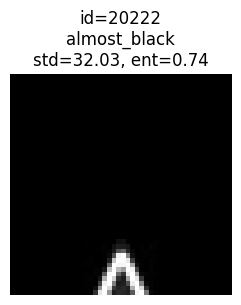

Không có ảnh nào với reason: low_contrast


In [47]:
# Ví dụ:
show_by_reason(full_df, reason='almost_black', n=20)
show_by_reason(full_df, reason='low_contrast', n=20)


## 13. Xuất file danh sách ảnh lỗi / nghi ngờ

File này dùng để:
- audit lại ảnh lỗi
- lưu danh sách row cần bỏ khi train
- theo dõi lý do từng ảnh


In [48]:
bad_samples_df = full_df[full_df['flag'] != 'ok'][[
    'row_id', 'emotion', 'Usage', 'flag', 'reason',
    'pixel_count', 'mean', 'std', 'min', 'max',
    'unique_count', 'zero_ratio', 'white_ratio', 'entropy'
]].copy()

bad_samples_path = Path(OUTPUT_DIR) / 'bad_samples.csv'
bad_samples_df.to_csv(bad_samples_path, index=False)
print('Đã lưu:', bad_samples_path)
display(bad_samples_df.head())


Đã lưu: ..\..\data\fer_data\cleaning_outputs\bad_samples.csv


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy
2059,2059,5,Training,review,very_bright,2304,245.425781,21.609312,86,255,122,0.0,0.051215,3.504083
2171,2171,6,Training,remove,very_low_std,2304,128.302951,0.637561,127,130,4,0.0,0.000000,1.395017
2809,2809,5,Training,review,very_bright,2304,248.087240,17.691603,151,255,86,0.0,0.118056,2.207127
3262,3262,5,Training,review,very_bright,2304,242.844618,23.055078,85,255,123,0.0,0.057726,3.820714
3931,3931,2,Training,review,very_bright,2304,242.663628,27.871670,119,255,122,0.0,0.680122,2.721012


## 14. Xuất file dữ liệu đã clean

Ở đây ta chỉ loại những ảnh có `flag = remove`.

Nhóm `review` vẫn giữ lại để bạn tự quyết định sau.


In [49]:
remove_ids = set(full_df.loc[full_df['flag'] == 'remove', 'row_id'].tolist())

clean_df = full_df[~full_df['row_id'].isin(remove_ids)][['emotion', 'pixels', 'Usage']].copy()

clean_csv_path = Path(OUTPUT_DIR) / 'train_cleaned.csv'
clean_df.to_csv(clean_csv_path, index=False)

print('Số dòng gốc      :', len(full_df))
print('Số dòng bị remove :', len(remove_ids))
print('Số dòng sau clean :', len(clean_df))
print('Đã lưu:', clean_csv_path)


Số dòng gốc      : 28709
Số dòng bị remove : 13
Số dòng sau clean : 28696
Đã lưu: ..\..\data\fer_data\cleaning_outputs\train_cleaned.csv


## 15. Tạo file chỉ chứa `row_id` cần remove

File này rất tiện nếu bạn muốn khi train chỉ cần đọc list row lỗi rồi bỏ qua.


In [50]:
remove_list_path = Path(OUTPUT_DIR) / 'remove_row_ids.txt'
with open(remove_list_path, 'w', encoding='utf-8') as f:
    for rid in sorted(remove_ids):
        f.write(f'{rid}\n')

print('Đã lưu:', remove_list_path)


Đã lưu: ..\..\data\fer_data\cleaning_outputs\remove_row_ids.txt


## 16. Cách dùng khi train

Nếu bạn không muốn tạo file clean mới, mà chỉ muốn bỏ các dòng lỗi khi train, có thể làm như sau.


In [51]:
def load_remove_ids(txt_path):
    with open(txt_path, 'r', encoding='utf-8') as f:
        ids = [int(line.strip()) for line in f if line.strip()]
    return set(ids)

# Ví dụ đọc lại file gốc
train_df = load_data(DATA_PATH)
remove_ids_loaded = load_remove_ids(remove_list_path)

# bỏ các dòng lỗi
train_df_filtered = train_df[~train_df['row_id'].isin(remove_ids_loaded)].reset_index(drop=True)

print('Train gốc     :', len(train_df))
print('Train filtered:', len(train_df_filtered))
display(train_df_filtered.head())


Train gốc     : 28709
Train filtered: 28696


,emotion,pixels,Usage,row_id
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,0
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,1
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,2
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,3
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,4


## 17. Hàm xem 1 ảnh cụ thể theo row_id

In [52]:
def show_image_by_row_id(dataframe, row_id):
    row = dataframe[dataframe['row_id'] == row_id]
    if len(row) == 0:
        print('Không tìm thấy row_id:', row_id)
        return

    row = row.iloc[0]
    arr = parse_pixels_fast(row['pixels'])
    if len(arr) != PIXEL_COUNT:
        print('Ảnh sai số lượng pixel:', len(arr))
        return

    img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    title = f"row_id={row['row_id']}, emotion={row['emotion']}, Usage={row['Usage']}"
    if 'flag' in dataframe.columns and 'reason' in dataframe.columns:
        title += f"\nflag={row['flag']}, reason={row['reason']}"
    plt.title(title)
    plt.axis('off')
    plt.show()


In [53]:
# Ví dụ xem 1 ảnh cụ thể
# show_image_by_row_id(full_df, 123)


## 18. Khuyến nghị sử dụng

Quy trình nên dùng:
1. Chạy scan toàn bộ
2. Xem thống kê `flag` và `reason`
3. Trực quan ảnh `remove` và `review`
4. Nếu rule hợp lý thì dùng `fer2013_cleaned.csv`
5. Nếu chưa chắc, chỉnh ngưỡng trong hàm `check_image_quality()` rồi quét lại

Lưu ý:
- Với FER-2013, không nên loại quá mạnh tay
- Chỉ nên `remove` các ảnh lỗi khá chắc chắn
- Nhóm `review` nên xem trực quan trước khi quyết định
